In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## Етап 1
**Первинний аналіз даних (EDA)**

Завантажую повний датасет Ames Housing (де `SalePrice` — цільова змінна)

In [2]:
url = "https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch09/AmesHousing.txt"
df = pd.read_csv(url, sep="\t")
print("Розмір датасету:", df.shape)
df.head()

Розмір датасету: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.head(15))

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
dtype: int64


In [5]:
df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

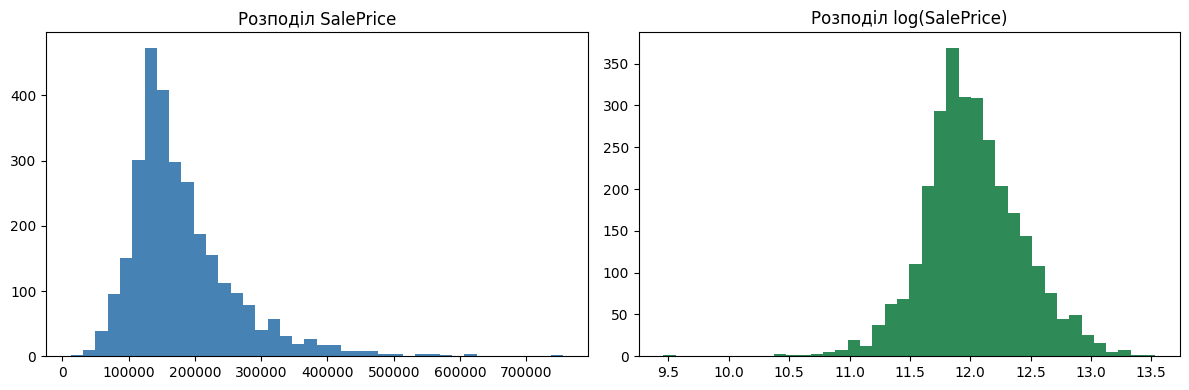

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['SalePrice'], bins=40, color='steelblue')
ax[0].set_title('Розподіл SalePrice')
ax[1].hist(np.log1p(df['SalePrice']), bins=40, color='seagreen')
ax[1].set_title('Розподіл log(SalePrice)')
plt.tight_layout()
plt.show()

**Висновок:** видно, що `SalePrice` розподілений не симетрично, бо є "хвіст" у бік
дорогих будинків (звичайна річ для цін на нерухомість). Для лінійної регресії це
потенційна проблема, бо залишки, швидше за все, теж не будуть нормальними. 
Я лишаю SalePrice як є (без логарифмування), бо так простіше, але цей момент згадую далі у висновках про нормальність.

**Відбір ознак**

Тепер треба зрозуміти, які колонки взагалі брати, не буду тягнути всі 82.
Рахую кореляцію числових ознак з `SalePrice` і дивлюсь, чи не корелюють ознаки
сильно одна з одною. Це можна робити ще до розбиття на train/test, бо тут я лише дивлюсь, 
які колонки взагалі варто залишити - жодних параметрів (середніх, std) я ще нізвідки не рахую.
А от коли дійде до імпутації/масштабування, там  вже рахуватиму все тільки на Train.

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Order', 'PID', 'SalePrice']]

corr_target = df[numeric_cols + ['SalePrice']].corr(numeric_only=True)['SalePrice'].drop('SalePrice')
corr_target = corr_target.sort_values(ascending=False)
print("Топ-15 числових ознак за кореляцією з SalePrice:")
print(corr_target.head(15))

Топ-15 числових ознак за кореляцією з SalePrice:
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Name: SalePrice, dtype: float64


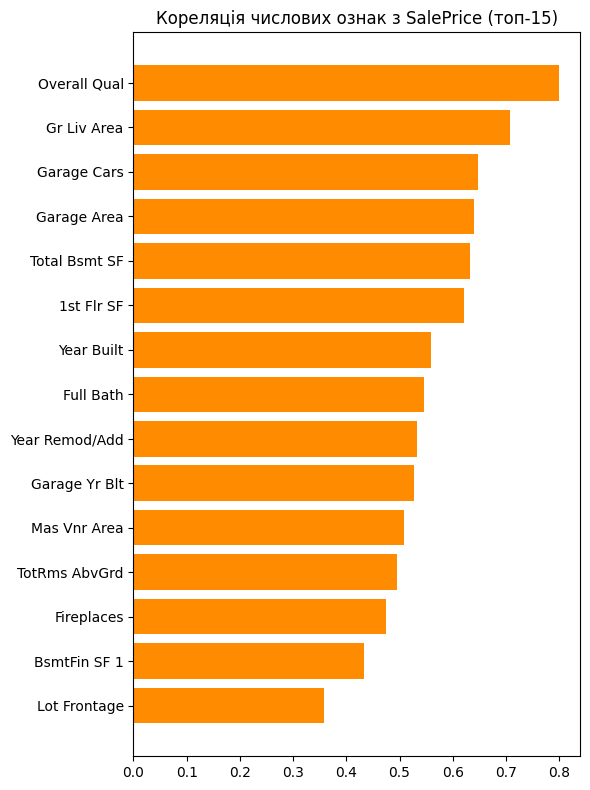

In [8]:
plt.figure(figsize=(6, 8))
top_corr = corr_target.head(15)
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color='darkorange')
plt.title('Кореляція числових ознак з SalePrice (топ-15)')
plt.tight_layout()
plt.show()

Обрані числові ознаки: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath']


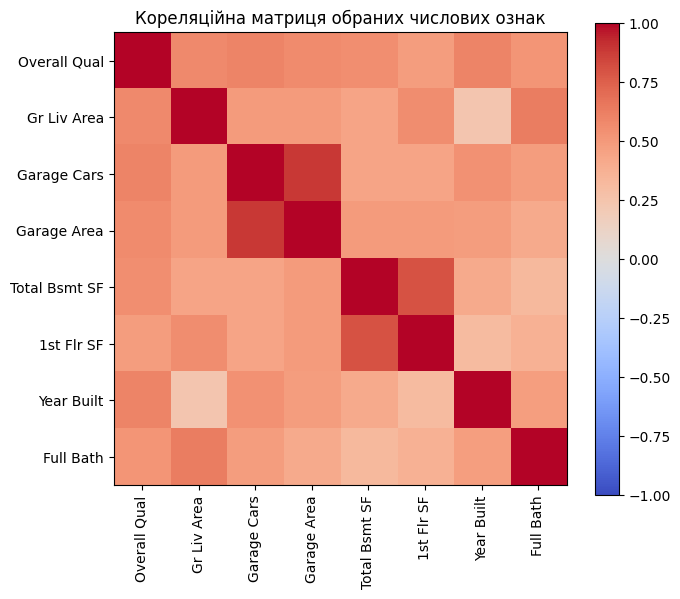

               Overall Qual  Gr Liv Area  Garage Cars  Garage Area  \
Overall Qual           1.00         0.57         0.60         0.56   
Gr Liv Area            0.57         1.00         0.49         0.48   
Garage Cars            0.60         0.49         1.00         0.89   
Garage Area            0.56         0.48         0.89         1.00   
Total Bsmt SF          0.55         0.44         0.44         0.49   
1st Flr SF             0.48         0.56         0.44         0.49   
Year Built             0.60         0.24         0.54         0.48   
Full Bath              0.52         0.63         0.48         0.41   

               Total Bsmt SF  1st Flr SF  Year Built  Full Bath  
Overall Qual            0.55        0.48        0.60       0.52  
Gr Liv Area             0.44        0.56        0.24       0.63  
Garage Cars             0.44        0.44        0.54       0.48  
Garage Area             0.49        0.49        0.48       0.41  
Total Bsmt SF           1.00        0.8

In [ ]:
# Candidates: 8 numerical features with the highest |correlation| with SalePrice
numeric_features = corr_target.abs().sort_values(ascending=False).head(8).index.tolist()
print("Обрані числові ознаки:", numeric_features)

# Checking for multicollinearity among the variables themselves
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(7, 6))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Кореляційна матриця обраних числових ознак')
plt.tight_layout()
plt.show()
print(corr_matrix.round(2))

**Обґрунтування вибору ознак.**
Взявла 8 числових ознак з найбільшою кореляцією до `SalePrice` : площа житла,
загальна якість, площа гаража і т.д. Логіка проста: якщо колонка сильно
корелює з ціною, вона, скоріш за все, буде корисна моделі. З матриці кореляцій
видно, що деякі пари ознак (наприклад `Garage Cars` і `Garage Area`) теж
корелюють між собою — це і є натяк на мультиколінеарність, її я перевірю
точніше через VIF на Етапі 5.

Категоріальні ознаки взявла чотири: `Neighborhood`, `Bldg Type`, `House Style`,
`Kitchen Qual`, бо здається логічним, що район і якість кухні впливають на ціну,
а числові колонки цю інформацію не покривають. Решту з 82 колонок не бравла -
там або забагато пропусків, або інформація дублює те, що вже є (наприклад,
кілька різних колонок про підвал).

In [10]:
categorical_features = ['Neighborhood', 'Bldg Type', 'House Style', 'Kitchen Qual']
feature_cols = numeric_features + categorical_features
print("Фінальний список ознак:", feature_cols)

data = df[feature_cols + ['SalePrice']].copy()
print("Пропуски у фінальному наборі:\n", data.isna().sum())

Фінальний список ознак: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Neighborhood', 'Bldg Type', 'House Style', 'Kitchen Qual']
Пропуски у фінальному наборі:
 Overall Qual     0
Gr Liv Area      0
Garage Cars      1
Garage Area      1
Total Bsmt SF    1
1st Flr SF       0
Year Built       0
Full Bath        0
Neighborhood     0
Bldg Type        0
House Style      0
Kitchen Qual     0
SalePrice        0
dtype: int64


In [ ]:
data = data.dropna(subset=['SalePrice'])
print(data.shape)

(2930, 13)


## Розбиття на Train/Validation/Test

**Питання: чому спліт треба робити ДО масштабування й кодування?**

Якщо порахувати mean/std для стандартизації (або, наприклад, Target Encoding)
на всьому датасеті одразу, а вже потім різати на train/test вийде, що
статистики для препроцесингу "підглянули" в test ще до того, як модель
взагалі почала вчитись. Це і називається **Data Leakage** (витік даних):
результат на test виглядатиме кращим, ніж модель покаже насправді на нових
даних, бо test непрямо вже "допоміг" препроцесингу. Тому правильно спочатку
розбити дані, а вже потім усі параметри (mean, std, категорії і т.д.)
рахувати тільки на Train і застосовувати їх до Validation/Test без
перерахунку.

In [12]:
X = data[feature_cols]
y = data['SalePrice'].values.astype(float)

# 60% train / 20% val / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1758, 12) Val: (586, 12) Test: (586, 12)


In [ ]:
num_medians = X_train[numeric_features].median()
cat_modes = X_train[categorical_features].mode().iloc[0]

for part in (X_train, X_val, X_test):
    part[numeric_features] = part[numeric_features].fillna(num_medians)
    part[categorical_features] = part[categorical_features].fillna(cat_modes)

print("Залишок пропусків у Train:", X_train.isna().sum().sum())

Залишок пропусків у Train: 0


## Кодування категоріальні ознаки

Обрала **One-Hot Encoding**. Причина: у `Neighborhood`, `Bldg Type`, `House Style`
немає природного порядку (не можна сказати, що один район "більший" за інший),
тому Ordinal тут не підходить. `Kitchen Qual` теоретично має порядок (Excellent >
Good > Average...), але я закодувала і її як one-hot, бо так простіше і не
доводиться вгадувати, чи однакова "відстань" між рівнями якості. Target Encoding
не бравла, бо він легко перенавчається на категоріях, де мало прикладів, і
вимагає обережнішої реалізації (крос-валідація всередині кодування).

**Питання: що робити з категоріями на Val/Test, яких не було в Train?**
Я використовую `OneHotEncoder(handle_unknown='ignore')`, тобто encoder навчається
тільки на Train, а якщо на Val/Test трапляється категорія, якої там не було,
вона просто отримує нульовий вектор замість помилки.

In [14]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_features])

def encode_cats(part):
    arr = encoder.transform(part[categorical_features])
    cols = encoder.get_feature_names_out(categorical_features)
    return pd.DataFrame(arr, columns=cols, index=part.index)

X_train_cat = encode_cats(X_train)
X_val_cat = encode_cats(X_val)
X_test_cat = encode_cats(X_test)
print("К-сть one-hot колонок:", X_train_cat.shape[1])

К-сть one-hot колонок: 45


## Масштабування

Стандартизую числові ознаки (`StandardScaler`, z-score). `mean` і `std` рахую
тільки на Train, а потім цим самим перетворенням масштабую Val і Test, щоб
не було витоку даних, про який писала вище.

In [15]:
scaler = StandardScaler()
scaler.fit(X_train[numeric_features])

X_train_num = pd.DataFrame(scaler.transform(X_train[numeric_features]),
                            columns=numeric_features, index=X_train.index)
X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]),
                          columns=numeric_features, index=X_val.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_features]),
                           columns=numeric_features, index=X_test.index)

X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_final = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

Xtr = X_train_final.values.astype(float)
Xva = X_val_final.values.astype(float)
Xte = X_test_final.values.astype(float)

ytr, yva, yte = y_train, y_val, y_test
print("Фінальна форма Train:", Xtr.shape)

Фінальна форма Train: (1758, 53)


## Етап 2 — Лінійна регресію на numpy

Модель: $\hat{y} = Xw + b$. Predict, MSE і градієнти рахую матричними операціями
numpy, без циклів `for` по прикладах 

In [16]:
class LinearRegressionNumpy:
    """Лінійна регресія з нуля на numpy: y_hat = X @ w + b."""

    def __init__(self, n_features):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.history = []  # cost per epoch

    def predict(self, X):
        return X @ self.w + self.b

    def compute_cost(self, X, y):
        """Mean Squared Error (з коефіцієнтом 1/2 для зручних градієнтів)."""
        m = X.shape[0]
        errors = self.predict(X) - y
        return np.sum(errors ** 2) / (2 * m)

    def compute_gradients(self, X, y):
        """Векторизовані градієнти MSE по w і b."""
        m = X.shape[0]
        errors = self.predict(X) - y          # (m,)
        dw = (X.T @ errors) / m               # (n_features,)
        db = np.sum(errors) / m               # scalar
        return dw, db

    def update_params(self, dw, db, lr):
        self.w -= lr * dw
        self.b -= lr * db

## Етап 3 — Три варіанти градієнтного спуску

Щоб графіки можна було чесно порівняти, я рахую cost на **повному Train** в
кінці кожної епохи для всіх трьох методів. Цикл `for` тут по епохах (і по
батчах у SGD/mini-batch), це і є сам алгоритм навчання, а не заміна
векторизованого рахунку градієнта (градієнт всередині циклу все одно рахується
матрично, одним виразом).

In [ ]:
def train_batch_gd(X, y, lr=0.1, epochs=200):
    model = LinearRegressionNumpy(X.shape[1])
    for epoch in range(epochs):
        dw, db = model.compute_gradients(X, y)
        model.update_params(dw, db, lr)
        model.history.append(model.compute_cost(X, y))
    return model


def train_sgd(X, y, lr=0.01, epochs=200, seed=42):
    rng = np.random.default_rng(seed)
    model = LinearRegressionNumpy(X.shape[1])
    m = X.shape[0]
    for epoch in range(epochs):
        idx = rng.permutation(m)
        for i in idx:
            xi = X[i:i+1]           
            yi = y[i:i+1]
            dw, db = model.compute_gradients(xi, yi)
            model.update_params(dw, db, lr)
        model.history.append(model.compute_cost(X, y))
    return model


def train_minibatch_gd(X, y, lr=0.05, epochs=200, batch_size=32, seed=42):
    rng = np.random.default_rng(seed)
    model = LinearRegressionNumpy(X.shape[1])
    m = X.shape[0]
    for epoch in range(epochs):
        idx = rng.permutation(m)
        X_sh, y_sh = X[idx], y[idx]
        for start in range(0, m, batch_size):
            xb = X_sh[start:start + batch_size]
            yb = y_sh[start:start + batch_size]
            dw, db = model.compute_gradients(xb, yb)
            model.update_params(dw, db, lr)
        model.history.append(model.compute_cost(X, y))
    return model

In [18]:
EPOCHS = 200
model_batch = train_batch_gd(Xtr, ytr, lr=0.3, epochs=EPOCHS)
model_sgd = train_sgd(Xtr, ytr, lr=0.01, epochs=EPOCHS)
model_mb = train_minibatch_gd(Xtr, ytr, lr=0.1, epochs=EPOCHS, batch_size=32)

print("Фінальний Train cost | Batch:", round(model_batch.history[-1], 2),
      "| SGD:", round(model_sgd.history[-1], 2),
      "| Mini-batch:", round(model_mb.history[-1], 2))

Фінальний Train cost | Batch: 426044761.4 | SGD: 416092744.12 | Mini-batch: 411787945.83


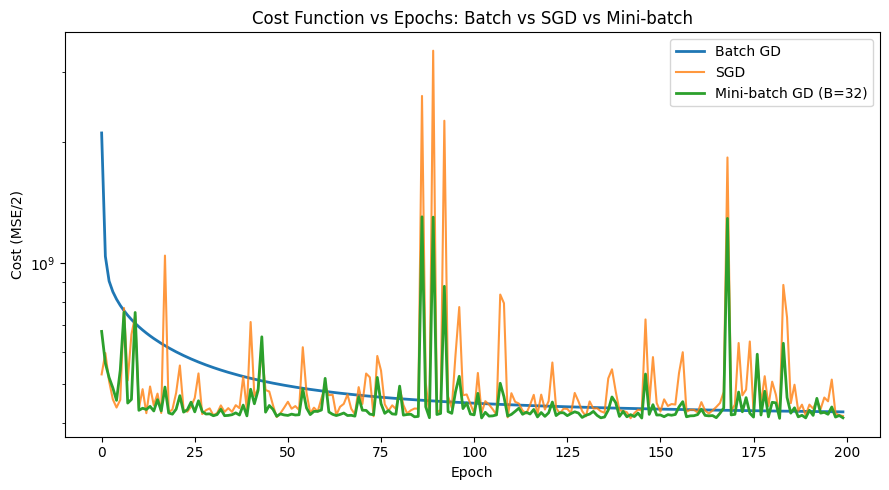

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(model_batch.history, label='Batch GD', linewidth=2)
plt.plot(model_sgd.history, label='SGD', alpha=0.8)
plt.plot(model_mb.history, label='Mini-batch GD (B=32)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE/2)')
plt.title('Cost Function vs Epochs: Batch vs SGD vs Mini-batch')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

**Аналіз графіків.**
- Найстабільніше себе поводить **Batch GD** - на кожному кроці рахується градієнт
  по всій вибірці одразу, тому лінія падає плавно, без стрибків.
- Найбільше коливається **SGD**, кожен крок рахується всього по одному прикладу,
  тому окреме оновлення легко "тягне" вагу не туди через шум конкретного
  прикладу; навіть cost в кінці епохи через це не завжди рівно спадає.
- **Mini-batch (B=32)** - щось середнє: усереднення по невеликому батчу
  згладжує шум SGD, але оновлень все одно більше, ніж у Batch GD, тож
  практично збіжність швидша.
- Щодо learning rate: для Batch GD можна брати більший α, бо градієнт точний.
  Для SGD і mini-batch довелось брати менший — з великим α через шум від
  окремих прикладів (SGD) чи батчів (mini-batch) модель або розходиться,
  або починає "стрибати" навколо мінімуму замість того, щоб до нього дійти.

## Етап 4 — Оцінка якості (R²)

$$R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

In [20]:
def r2_score_numpy(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


def report_r2(model, name):
    r2_tr = r2_score_numpy(ytr, model.predict(Xtr))
    r2_va = r2_score_numpy(yva, model.predict(Xva))
    r2_te = r2_score_numpy(yte, model.predict(Xte))
    print(f"{name:15s} | Train R2={r2_tr: .4f} | Val R2={r2_va: .4f} | Test R2={r2_te: .4f}")
    return r2_tr, r2_va, r2_te


results = {}
results['Batch GD'] = report_r2(model_batch, 'Batch GD')
results['SGD'] = report_r2(model_sgd, 'SGD')
results['Mini-batch GD'] = report_r2(model_mb, 'Mini-batch GD')

Batch GD        | Train R2= 0.8591 | Val R2= 0.7976 | Test R2= 0.8705
SGD             | Train R2= 0.8624 | Val R2= 0.7940 | Test R2= 0.8716
Mini-batch GD   | Train R2= 0.8639 | Val R2= 0.8004 | Test R2= 0.8699


**Що означає R².** це те, наскільки краще моя модель
передбачає ціну порівняно з тим, якби я просто завжди називала середню ціну
по всій вибірці. R²=1 означає ідеальний прогноз, R²=0 - модель не краща за
"завжди відповідати середнім".

**Чи може R² бути від'ємним?** Так, може якщо модель настільки погана, що
помиляється більше, ніж просте вгадування середнім (наприклад, через
невдалий learning rate або замало епох), сума квадратів помилок моделі
($SS_{res}$) вийде більшою за загальну дисперсію ($SS_{tot}$), і R² піде в мінус.

**Train vs Test.** У мене R² на Train і Test вийшли досить близькими (див.
цифри вище) - це добре, значить модель не перенавчилась сильно і більш-менш
однаково працює і на даних, які бачила, і на нових. Якби Train R² був
помітно вищим за Test це був би сигнал overfitting.

**Порівняння трьох GD.** У мене всі три методи дали приблизно однаковий R²
(різниця в тисячних-сотих). Це логічно: за достатню кількість епох і при
більш-менш вдало підібраному learning rate всі три способи мають зійтись до
схожого рішення, просто Batch GD робить це найплавніше, а SGD/mini-batch —
трохи "шумніше" по дорозі.

## Етап 5 — Перевірка статистичних припущень

Беру модель Batch GD (вона показала стабільно хороший R²) і дивлюсь на її
залишки $\epsilon = y - \hat y$ на Train.

In [21]:
y_pred_train = model_batch.predict(Xtr)
residuals = ytr - y_pred_train

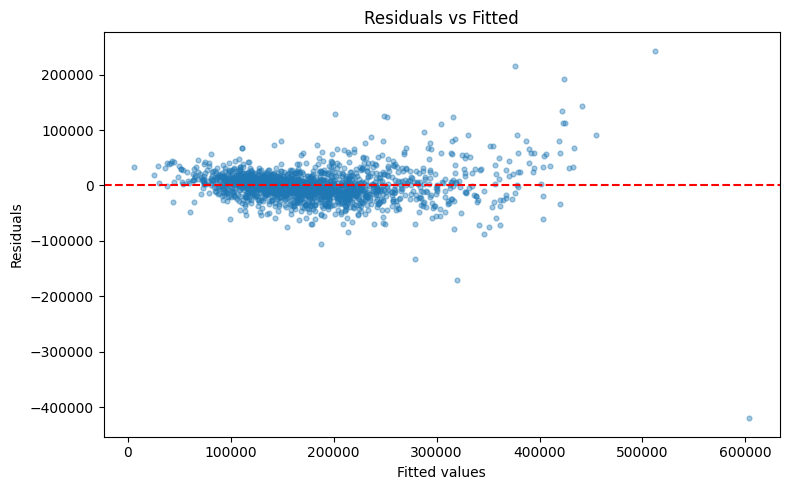

In [ ]:
plt.figure()
plt.scatter(y_pred_train, residuals, alpha=0.4, s=12)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

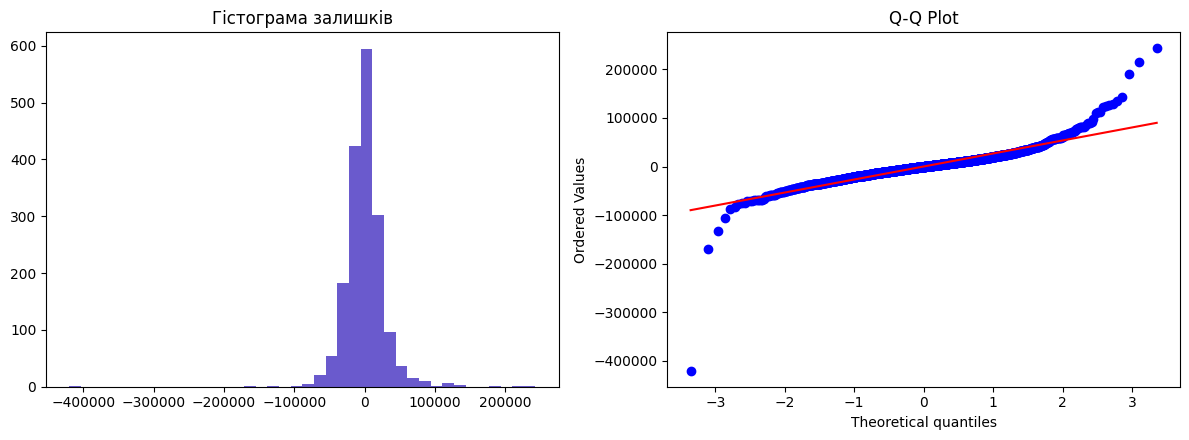

Shapiro-Wilk: statistic=0.8427, p-value=0.000000


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(residuals, bins=40, color='slateblue')
ax[0].set_title('Гістограма залишків')

stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

sample = np.random.choice(residuals, size=min(2000, len(residuals)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")


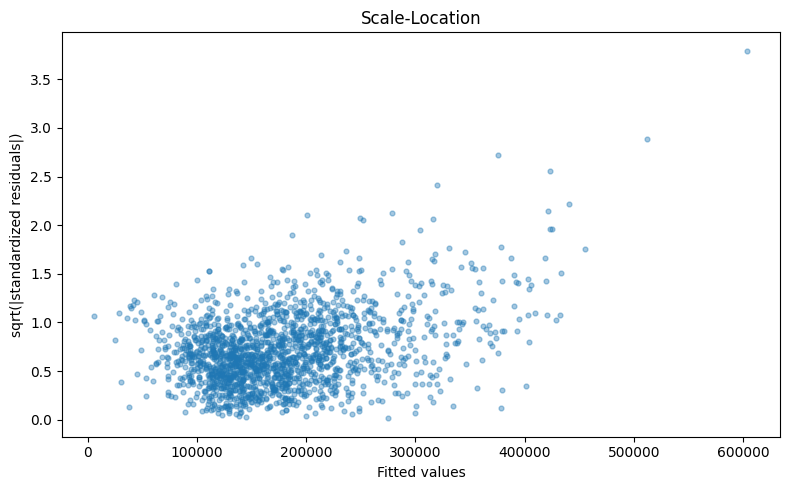

In [24]:
# 3. Homoscedasticity: Scale-Location plot
sqrt_abs_resid = np.sqrt(np.abs(residuals - residuals.mean()) / residuals.std())
plt.figure()
plt.scatter(y_pred_train, sqrt_abs_resid, alpha=0.4, s=12)
plt.xlabel('Fitted values')
plt.ylabel('sqrt(|standardized residuals|)')
plt.title('Scale-Location')
plt.tight_layout()
plt.show()

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features
vif_data["VIF"] = [variance_inflation_factor(X_train_num.values, i) for i in range(len(numeric_features))]
print(vif_data.sort_values("VIF", ascending=False))

         feature       VIF
2    Garage Cars  5.625773
3    Garage Area  5.196841
5     1st Flr SF  3.794554
4  Total Bsmt SF  3.652060
1    Gr Liv Area  2.636127
0   Overall Qual  2.402574
7      Full Bath  2.089175
6     Year Built  1.995792


**Висновки за припущеннями.**

- **Лінійність.** на графіку Residuals vs Fitted точки більш-менш розкидані
  навколо нуля без явної дуги чи форми, схожої на параболу — тобто припущення
  лінійності виконується непогано. Якби була видима крива, це означало б, що
  реальна залежність нелінійна і моя модель систематично помиляється в певних
  діапазонах цін.

- **Нормальність.** тест Шапіро-Уїлка дав p-value набагато менше 0.05 (див.
  цифру вище), тобто гіпотезу про нормальність залишків доводиться відхилити —
  припущення **порушується**. Це не дивно, бо ще на самому початку (EDA) я
  бачив(ла), що `SalePrice` має асиметричний розподіл. Це означає, що якщо
  захотіти рахувати класичні довірчі інтервали чи p-значення для коефіцієнтів
  — вони будуть не зовсім коректними, хоча на сам прогноз (R², помилку) це
  впливає не так сильно.

- **Гомоскедастичність.** на графіку Scale-Location дивлюсь, чи розкид точок
  однаковий по всій осі X, чи росте разом з fitted values (форма "лійки").
  Якщо розкид зростає - це гетероскедастичність, і це означає, що для дорожчих
  будинків модель помиляється сильніше, тобто похибка прогнозу непостійна.

- **Мультиколінеарність (VIF).** Найвищий VIF вийшов у `Garage Cars` і
  `Garage Area` (~5.2–5.6) - це очікувано, бо це фактично дві версії однієї
  інформації (більше машиномісць → більша площа гаража). Значення не дуже
  високі (за поріг 10 не виходять), тому це не критично, але означає, що
  коефіцієнти саме цих двох ознак не варто інтерпретувати окремо один від
  одного — вони частково "ділять" між собою вплив на ціну, і невеликі зміни
  в даних можуть змінити, якій з двох ознак модель віддасть більшу вагу.
  Якби мультиколінеарність була сильнішою, мало б сенс прибрати одну з пари
  ознак або спробувати Ridge-регресію (L2-регуляризацію), яка якраз стягує
  ваги колінеарних ознак і робить їх стабільнішими.

## Етап 6 — Експеримент А: вплив масштабування

Порівнюємо Mini-batch GD на немасштабованих даних і на стандартизованих.

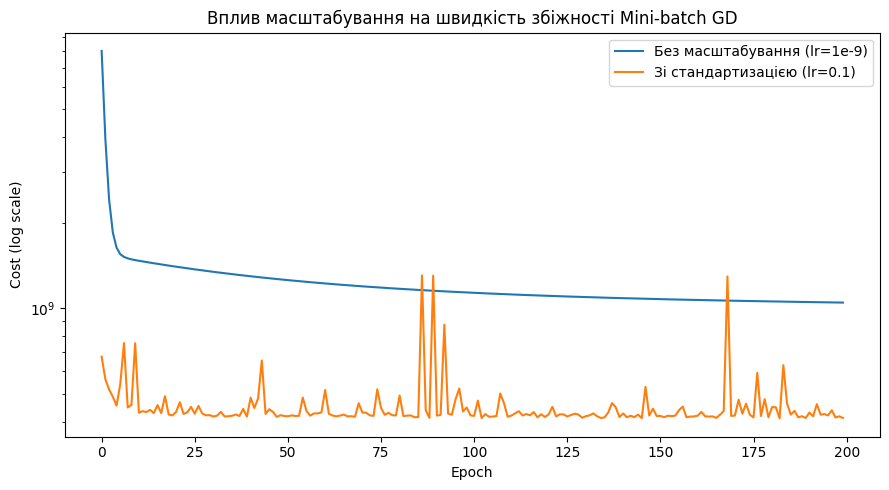

Фінальний cost без масштабування: 1047070817.9025301
Фінальний cost зі масштабуванням: 411787945.8332608


In [ ]:
X_train_raw = pd.concat([X_train[numeric_features].reset_index(drop=True),
                          X_train_cat.reset_index(drop=True)], axis=1).values.astype(float)

model_unscaled = train_minibatch_gd(X_train_raw, ytr, lr=1e-9, epochs=EPOCHS, batch_size=32)
model_scaled = train_minibatch_gd(Xtr, ytr, lr=0.1, epochs=EPOCHS, batch_size=32)

plt.figure(figsize=(9, 5))
plt.plot(model_unscaled.history, label='Без масштабування (lr=1e-9)')
plt.plot(model_scaled.history, label='Зі стандартизацією (lr=0.1)')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cost (log scale)')
plt.title('Вплив масштабування на швидкість збіжності Mini-batch GD')
plt.legend()
plt.tight_layout()
plt.show()

print("Фінальний cost без масштабування:", model_unscaled.history[-1])
print("Фінальний cost зі масштабуванням:", model_scaled.history[-1])

**Геометричне пояснення.** Без масштабування ознаки
мають зовсім різні діапазони: `Lot Area` — десятки тисяч, а `Overall Qual` —
цифри від 1 до 10. Якщо уявити поверхню функції втрат як "чашу" в просторі
ваг, то через таку різницю в масштабах ця чаша виходить сильно витягнутою,
схожою на вузький яр, а не на кругле дно. Вздовж "довгої" ознаки (Lot Area)
градієнт величезний, вздовж "короткої" — крихітний. Один спільний learning
rate тоді або занадто малий для одного напрямку (навчання повзе), або
занадто великий для іншого (все "вибухає"). Тому мені й довелось брати
для немасштабованих даних настільки крихітний α (1e-9), інакше градієнт
одразу йшов у нескінченність. Після стандартизації всі ознаки мають
приблизно однаковий масштаб (mean≈0, std≈1), "чаша" стає набагато більш
округлою, і градієнтний спуск може йти прямо до мінімуму з нормальним,
набагато більшим кроком.

## Загальний висновок

Спочатку розібралась з датасетом Ames Housing: подивилась на пропуски, на
розподіл `SalePrice` (він виявився асиметричним - це потім "аукнулось" на
Етапі 5, коли перевіряла нормальність залишків). З 82 колонок обрала 8
числових (найбільш скорельованих з ціною) і 4 категоріальні - і пояснила,
чому саме їх, а не всі підряд.

Дані розбила на Train/Validation/Test **до** будь-якого препроцесингу - і
окремо пояснила, чому інакше вийшов би Data Leakage. Категорії закодувала
One-Hot Encoding'ом (з `handle_unknown='ignore'` на випадок нових категорій
на Val/Test), а числові ознаки стандартизувала - причому і mean/std для
масштабування, і медіани для заповнення пропусків рахувала тільки на Train.

Лінійну регресію (`ŷ = Xw + b`) написала сама на numpy - і predict, і MSE,
і градієнти рахуються матрично, без жодного `for` по прикладах. На цій
моделі навчила три варіанти градієнтного спуску (Batch, SGD, Mini-batch) і
порівняла їх на графіку: Batch виявився найплавнішим, SGD - найшумнішим,
Mini-batch - десь посередині, як і мало бути за теорією.

Якість перевірила через R², у всіх
трьох методів вийшло приблизно однаково (Test R² ≈ 0.87), і Train з Test
близькі, тобто модель не перенавчилась.

Далі перевірила чотири статистичні припущення лінійної регресії:
лінійність - більш-менш ок; нормальність залишків - **порушена**
(Shapiro-Wilk p-value << 0.05, що логічно з огляду на асиметричний
`SalePrice`); стабільність розкиду помилок оцінила через Scale-Location; і
мультиколінеарність через VIF - знайшла помірну колінеарність між
`Garage Cars` і `Garage Area` (VIF ≈ 5.2-5.6), не критичну, але помітну.

Насамкінець зробила Експеримент А - порівняла Mini-batch GD з масштабуванням
і без. Різниця вражаюча: без стандартизації довелось брати learning rate у
мільярд разів менший, інакше градієнт просто "вибухав". Пояснила це
геометрично через форму функції втрат (витягнута "чаша" замість круглої).